# 06 — Autoencoder + MLP

Standalone notebook. Run `00_Preprocessing.ipynb` first.

The autoencoder is trained **unsupervised** on the original (pre-SMOTE)
training data — it doesn't need class balance. The trained encoder then
compresses the SMOTE-resampled training data and the test data; an MLP
classifier is trained on top of that compressed representation.

In [1]:
import os, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, evaluate, save_results

SEED = 42
tf.random.set_seed(SEED)
MODEL_NAME = "Autoencoder+MLP"
DL_EPOCHS = 20
DL_BATCH_SIZE = 256
ENCODING_DIM = 16


## Load Preprocessed Data

In [2]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))            # pre-SMOTE, for unsupervised AE training
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
y_train_res = np.load(os.path.join(PROCESSED_DIR, "y_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

print(f"AE train (pre-SMOTE): {X_train.shape}, MLP train (post-SMOTE): {X_train_res.shape}, Test: {X_test.shape}")


AE train (pre-SMOTE): (214325, 78), MLP train (post-SMOTE): (911664, 78), Test: (53582, 78)


## Build & Train Autoencoder (unsupervised)

In [3]:
def build_autoencoder(input_dim, encoding_dim):
    inputs = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(64, activation="relu")(inputs)
    encoded = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(encoded)
    decoded = layers.Dense(64, activation="relu")(encoded)
    decoded = layers.Dense(input_dim, activation="linear")(decoded)
    autoencoder = models.Model(inputs, decoded)
    encoder = models.Model(inputs, encoded)
    autoencoder.compile(optimizer="adam", loss="mse")
    return autoencoder, encoder


autoencoder, encoder = build_autoencoder(X_train.shape[1], ENCODING_DIM)

t0 = time.time()
ae_history = autoencoder.fit(
    X_train, X_train, validation_split=0.1,
    epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=2,
)
ae_train_time = time.time() - t0
print(f"Autoencoder train time: {ae_train_time:.2f}s")


Epoch 1/20
754/754 - 4s - 6ms/step - loss: 0.3373 - val_loss: 0.2421
Epoch 2/20
754/754 - 5s - 7ms/step - loss: 0.1741 - val_loss: 0.1219
Epoch 3/20
754/754 - 3s - 4ms/step - loss: 0.1513 - val_loss: 0.1125
Epoch 4/20
754/754 - 3s - 4ms/step - loss: 0.1373 - val_loss: 0.0985
Epoch 5/20
754/754 - 3s - 4ms/step - loss: 0.1067 - val_loss: 0.0901
Epoch 6/20
754/754 - 3s - 4ms/step - loss: 0.1010 - val_loss: 0.0851
Epoch 7/20
754/754 - 3s - 4ms/step - loss: 0.0815 - val_loss: 0.0722
Epoch 8/20
754/754 - 3s - 4ms/step - loss: 0.1065 - val_loss: 0.0753
Epoch 9/20
754/754 - 3s - 4ms/step - loss: 0.0694 - val_loss: 0.0775
Epoch 10/20
754/754 - 3s - 4ms/step - loss: 0.0624 - val_loss: 0.1473
Autoencoder train time: 35.70s


## Encode Data & Train MLP Classifier

In [4]:
X_train_encoded = encoder.predict(X_train_res, verbose=0)
X_test_encoded = encoder.predict(X_test, verbose=0)

def build_mlp(input_dim, n_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


model = build_mlp(ENCODING_DIM, n_classes)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

t0 = time.time()
history = model.fit(
    X_train_encoded, y_train_res, validation_split=0.1,
    epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
    callbacks=[early_stop], verbose=2,
)
mlp_train_time = time.time() - t0
train_time = ae_train_time + mlp_train_time  # total pipeline time
print(f"MLP train time: {mlp_train_time:.2f}s | Total (AE + MLP): {train_time:.2f}s")


Epoch 1/20
3206/3206 - 19s - 6ms/step - accuracy: 0.8612 - loss: 0.4365 - val_accuracy: 0.4102 - val_loss: 6.9847
Epoch 2/20
3206/3206 - 16s - 5ms/step - accuracy: 0.9448 - loss: 0.1706 - val_accuracy: 0.4111 - val_loss: 4.9671
Epoch 3/20
3206/3206 - 19s - 6ms/step - accuracy: 0.9547 - loss: 0.1378 - val_accuracy: 0.4093 - val_loss: 4.8097
Epoch 4/20
3206/3206 - 17s - 5ms/step - accuracy: 0.9588 - loss: 0.1256 - val_accuracy: 0.4155 - val_loss: 4.6497
Epoch 5/20
3206/3206 - 17s - 5ms/step - accuracy: 0.9611 - loss: 0.1163 - val_accuracy: 0.4114 - val_loss: 4.6328
Epoch 6/20
3206/3206 - 17s - 5ms/step - accuracy: 0.9624 - loss: 0.1129 - val_accuracy: 0.4128 - val_loss: 4.6105
Epoch 7/20
3206/3206 - 16s - 5ms/step - accuracy: 0.9641 - loss: 0.1069 - val_accuracy: 0.4124 - val_loss: 4.5516
Epoch 8/20
3206/3206 - 17s - 5ms/step - accuracy: 0.9649 - loss: 0.1046 - val_accuracy: 0.4121 - val_loss: 3.9856
Epoch 9/20
3206/3206 - 16s - 5ms/step - accuracy: 0.9661 - loss: 0.1006 - val_accuracy: 

## Predict & Evaluate

In [5]:
t0 = time.time()
y_proba = model.predict(X_test_encoded, verbose=0)
infer_time = time.time() - t0
y_pred = np.argmax(y_proba, axis=1)

row = evaluate(MODEL_NAME, y_test, y_pred, y_proba, train_time, infer_time, n_classes)
for k, v in row.items():
    if k not in ("Confusion Matrix",):
        print(f"{k}: {v}")


Model: Autoencoder+MLP
Accuracy: 0.9374230151916688
Precision: 0.4629318543556465
Recall: 0.837415614176364
F1-Score: 0.5475955776635348
ROC-AUC: nan
MCC: 0.8412633107532511
Cohen's Kappa: 0.8301143944286458
Train Time (s): 222.89006114006042
Prediction Time (s): 2.202998638153076


## Training Curves

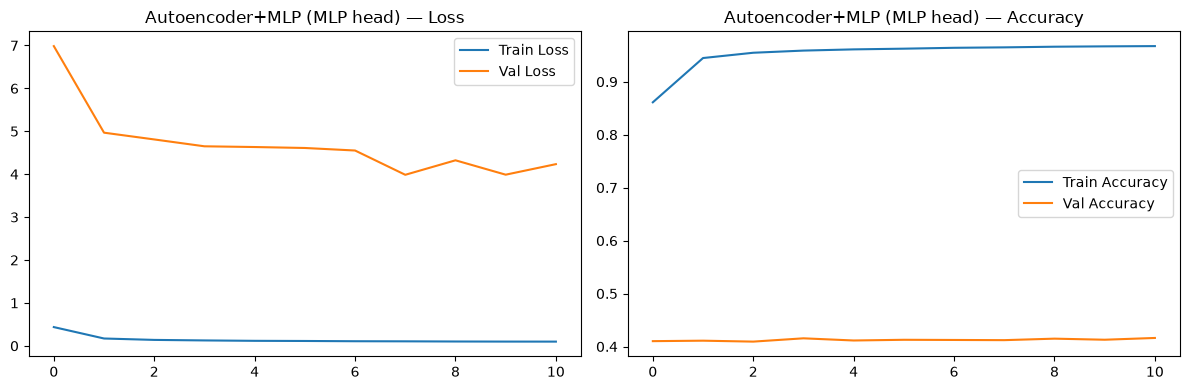

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title(f"{MODEL_NAME} (MLP head) — Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title(f"{MODEL_NAME} (MLP head) — Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "AutoencoderMLP_training_curves.png"), dpi=150)
plt.show()


## Confusion Matrix Plot

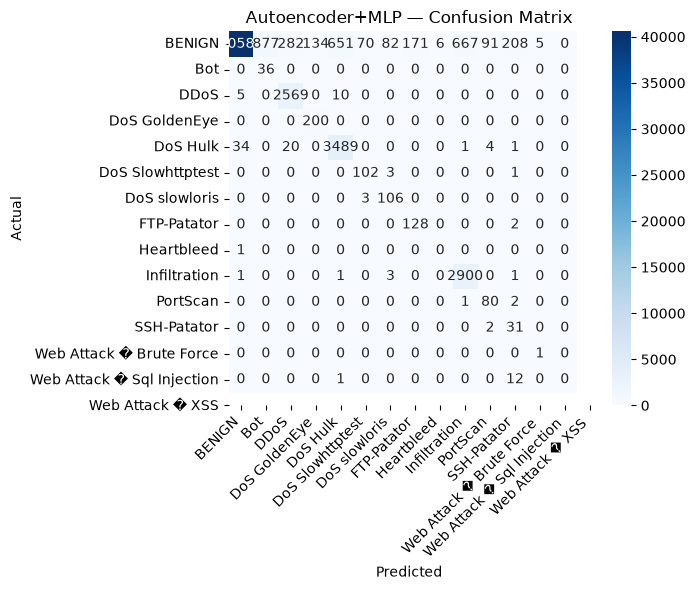

In [7]:
cm = np.array(row["Confusion Matrix"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "AutoencoderMLP_confusion_matrix.png"), dpi=150)
plt.show()


## Save Results & Models

In [8]:
save_results(MODEL_NAME, row, history=history.history)
model.save(os.path.join(MODELS_DIR, "AutoencoderMLP_classifier.keras"))
encoder.save(os.path.join(MODELS_DIR, "AutoencoderMLP_encoder.keras"))
print("Saved model and results for", MODEL_NAME)


Saved results to results\AutoencoderMLP_results.json
Saved model and results for Autoencoder+MLP
